In [41]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
import seaborn as sns
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import point_query
from rasterio.features import geometry_mask



In [42]:
dst_file = r"C:\Users\bsf31\Documents\data\NM\meta\mod_nodata\canopy_height_silver_city_utm12_1m.tif"


In [43]:
# Open the raster file
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)  # Read the first band
    pixel_area = src.res[0] * src.res[1]  # Area of each pixel in square meters

In [44]:
pixel_area

1.0

## Overstory Statistics (Height > 2 meters) Entire Extent

In [45]:
# Conversion factor
meters_to_feet = 3.28084
square_meters_to_square_feet = 10.7639

In [46]:
canopy_threshold = 2  # Minimum height in meters for a pixel to be considered canopy

In [47]:
# Mask canopy pixels above threshold
canopy_mask = canopy_data >= canopy_threshold

In [48]:
# Calculate the total area of canopy cover
canopy_area = np.sum(canopy_mask) * pixel_area  # Area in square meters
canopy_area_hectares = canopy_area / 10000  # Convert to hectares

In [49]:
canopy_area_sqft = canopy_area * square_meters_to_square_feet  # Convert to square feet


In [50]:
canopy_heights = canopy_data[canopy_mask]  # Extract heights where canopy exists

In [51]:
# Convert heights to feet for plotting
canopy_heights_ft = canopy_heights * meters_to_feet

In [52]:
# Convert height statistics to feet
mean_height_ft = np.mean(canopy_heights_ft) 
median_height_ft = np.median(canopy_heights_ft) 
min_height_ft = np.min(canopy_heights_ft) 
max_height_ft = np.max(canopy_heights_ft) 
std_dev_height_ft= np.std(canopy_heights_ft) 

In [53]:
print("Canopy Height Statistics:")
print(f"Mean Height: {mean_height_ft:.2f} feet")
print(f"Median Height: {median_height_ft:.2f} feet")
print(f"Minimum Height: {min_height_ft:.2f} feet")
print(f"Maximum Height: {max_height_ft:.2f} feet")
print(f"Standard Deviation of Height: {std_dev_height_ft:.2f} feet")

Canopy Height Statistics:
Mean Height: 10.94 feet
Median Height: 9.84 feet
Minimum Height: 6.56 feet
Maximum Height: 82.02 feet
Standard Deviation of Height: 5.38 feet


# Understory/Overstory Stats by Region

In [54]:
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
gdf = gpd.read_file(nm_path, layer='sc_etj_limit')

In [55]:
def canopy_area(arr, mask):
    valid_data = np.isfinite(arr) & (arr >= canopy_threshold)
    return np.sum(valid_data) * pixel_area * square_meters_to_square_feet

In [56]:
# Define the updated canopy_stats function
def canopy_stats(arr, mask):
    arr = np.ma.array(arr)         # Convert to masked array
    canopy = arr[(arr >= 2)].compressed()  # Only valid values, >= 2
    
    # Ensure it's not empty
    if canopy.size == 0:
        return {
            "canopy_mean": None,
            "canopy_median": None,
            "canopy_min": None,
            "canopy_max": None,
            "canopy_std": None
        }
    
    return {
        "canopy_mean": np.mean(canopy),
        "canopy_median": np.median(canopy),
        "canopy_min": np.min(canopy),
        "canopy_max": np.max(canopy),
        "canopy_std": np.std(canopy)
    }


In [57]:
""" # Calculate zonal statistics for each polygon in hurley_gdf
stats = zonal_stats(
    gdf,
    dst_file,
    stats=["mean", "median", "min", "max", "std"],
    add_stats={'area': canopy_area},
    prefix="canopy_"
)
zonal_df = pd.DataFrame(stats)
gdf = gdf.join(zonal_df)
 """


' # Calculate zonal statistics for each polygon in hurley_gdf\nstats = zonal_stats(\n    gdf,\n    dst_file,\n    stats=["mean", "median", "min", "max", "std"],\n    add_stats={\'area\': canopy_area},\n    prefix="canopy_"\n)\nzonal_df = pd.DataFrame(stats)\ngdf = gdf.join(zonal_df)\n '

In [58]:
stats = zonal_stats(
    gdf,
    dst_file,
    add_stats={
        'canopy_area': canopy_area,
        'canopy_mean': lambda arr, mask: canopy_stats(arr, mask)["canopy_mean"],
        'canopy_median': lambda arr, mask: canopy_stats(arr, mask)["canopy_median"],
        'canopy_min': lambda arr, mask: canopy_stats(arr, mask)["canopy_min"],
        'canopy_max': lambda arr, mask: canopy_stats(arr, mask)["canopy_max"],
        'canopy_std': lambda arr, mask: canopy_stats(arr, mask)["canopy_std"],
    }
)



In [59]:
zonal_df = pd.DataFrame(stats)
gdf = gdf.join(zonal_df)

In [60]:
# Convert height statistics to feet
gdf['area'] *= square_meters_to_square_feet
gdf['canopy_mean'] *= meters_to_feet
gdf['canopy_median'] *= meters_to_feet
gdf['canopy_min'] *= meters_to_feet
gdf['canopy_max'] *= meters_to_feet
gdf['canopy_std'] *= meters_to_feet


In [61]:
# Group by 'temp_name' to get aggregated canopy statistics
grouped_stats = gdf.groupby("place").agg({
    'canopy_mean':'mean',
    'canopy_median':'mean',
    'canopy_min': 'min',
    'canopy_max': 'max',
    'canopy_std': 'mean',
    'canopy_area': 'sum'
}).reset_index()

In [62]:
grouped_stats

,place,canopy_mean,canopy_median,canopy_min,canopy_max,canopy_std,canopy_area
0,City Limit,13.588872,13.12336,6.56168,68.89764,7.065915,1.321136e+07
1,ETJ,10.791250,9.84252,6.56168,82.02100,5.229162,2.281112e+08


In [63]:
# Total canopy cover % for entire study area (based on all vegetation > 2m)
total_canopy_area = gdf['canopy_area'].sum()
total_area = gdf['area'].sum()

total_canopy_cover_percent = (total_canopy_area / total_area) * 100
print(f"Total Tree Canopy Cover for Study Area: {total_canopy_cover_percent:.2f}%")


Total Tree Canopy Cover for Study Area: 9.69%


In [64]:
sns.set_theme(style="whitegrid", palette="pastel")


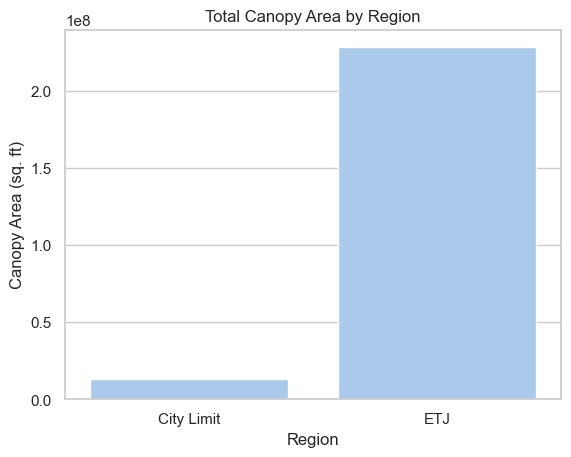

In [65]:
sns.barplot(x='place', y='canopy_area', data=grouped_stats)
plt.title('Total Canopy Area by Region')
plt.xlabel('Region')
plt.ylabel('Canopy Area (sq. ft)')
plt.show()

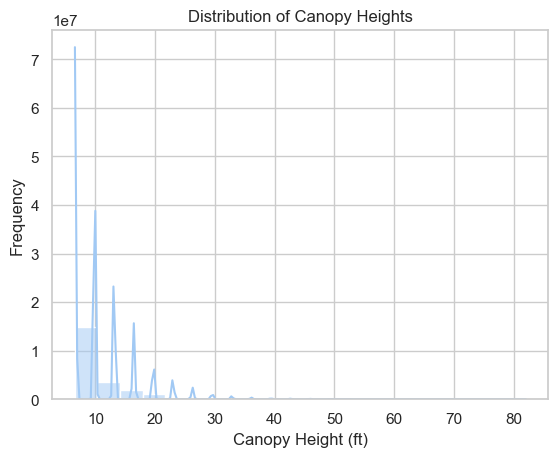

In [66]:
sns.histplot(canopy_heights_ft, bins=20, kde=True)
plt.title('Distribution of Canopy Heights')
plt.xlabel('Canopy Height (ft)')
plt.ylabel('Frequency')
plt.show()


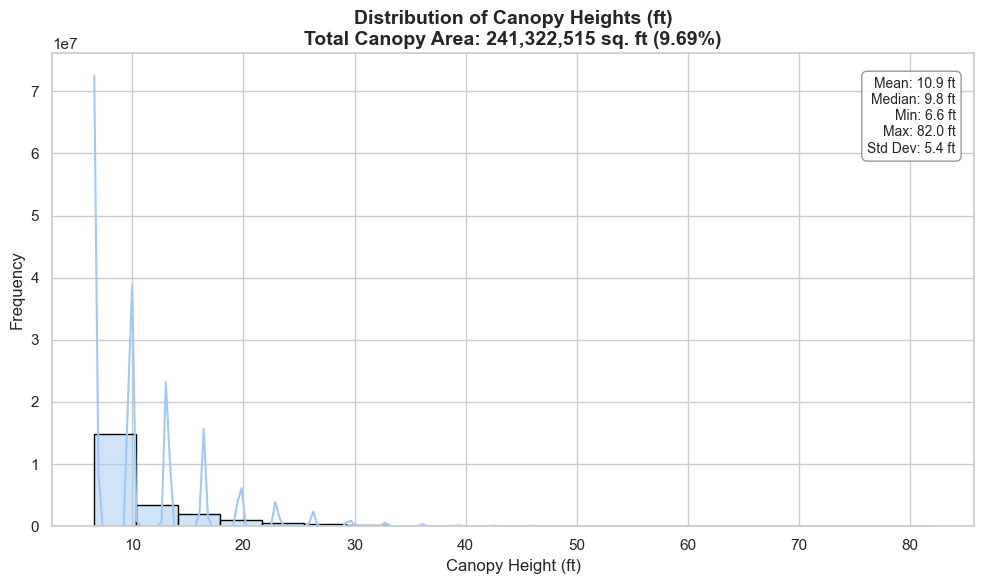

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(canopy_heights_ft, bins=20, kde=True,  edgecolor="black", ax=ax)

# Axis labels and title
ax.set_title(
    f"Distribution of Canopy Heights (ft)\n"
    f"Total Canopy Area: {total_canopy_area:,.0f} sq. ft "
    f"({total_canopy_cover_percent:.2f}%)",
    fontsize=14,
    weight='bold'
)
plt.xlabel('Canopy Height (ft)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Summary statistics text box
stats_text = (
    f"Mean: {mean_height_ft:.1f} ft\n"
    f"Median: {median_height_ft:.1f} ft\n"
    f"Min: {min_height_ft:.1f} ft\n"
    f"Max: {max_height_ft:.1f} ft\n"
    f"Std Dev: {std_dev_height_ft:.1f} ft"
)

# Position text box in top right corner
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10, ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)



plt.tight_layout()
plt.show()

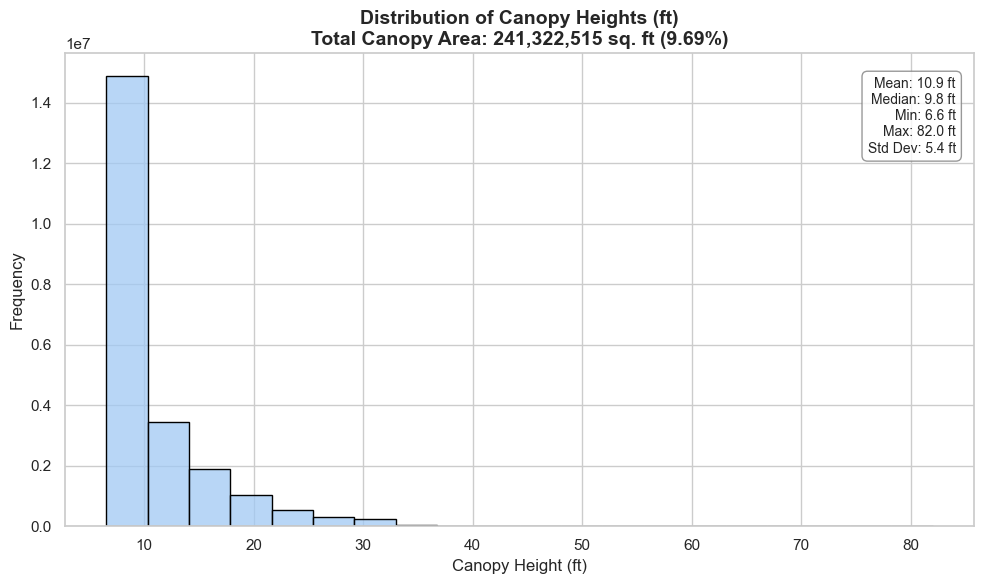

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(canopy_heights_ft, bins=20, kde=False,  edgecolor="black", ax=ax)

# Axis labels and title
ax.set_title(
    f"Distribution of Canopy Heights (ft)\n"
    f"Total Canopy Area: {total_canopy_area:,.0f} sq. ft "
    f"({total_canopy_cover_percent:.2f}%)",
    fontsize=14,
    weight='bold'
)
plt.xlabel('Canopy Height (ft)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Summary statistics text box
stats_text = (
    f"Mean: {mean_height_ft:.1f} ft\n"
    f"Median: {median_height_ft:.1f} ft\n"
    f"Min: {min_height_ft:.1f} ft\n"
    f"Max: {max_height_ft:.1f} ft\n"
    f"Std Dev: {std_dev_height_ft:.1f} ft"
)

# Position text box in top right corner
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10, ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)



plt.tight_layout()
plt.show()

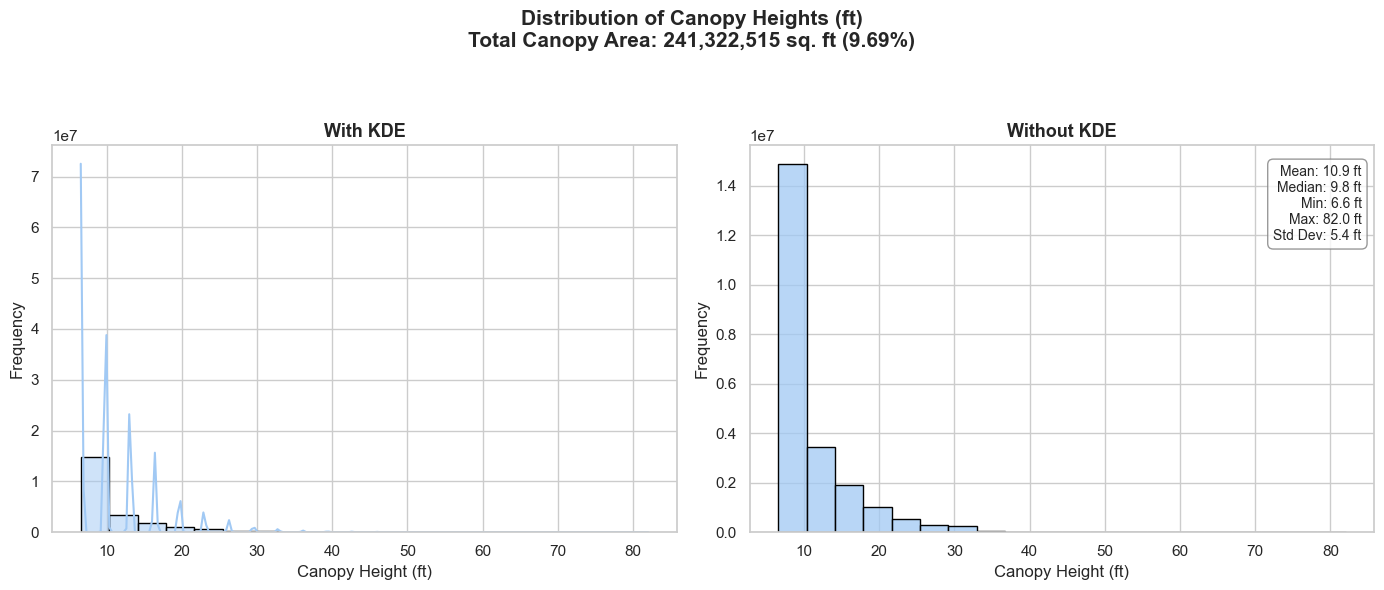

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # Removed sharey=True

# --- Histogram with KDE ---
sns.histplot(canopy_heights_ft, bins=20, kde=True, edgecolor="black", ax=axes[0])
axes[0].set_title("With KDE", fontsize=13, weight='bold')
axes[0].set_xlabel("Canopy Height (ft)")
axes[0].set_ylabel("Frequency")

# --- Histogram without KDE ---
sns.histplot(canopy_heights_ft, bins=20, kde=False, edgecolor="black", ax=axes[1])
axes[1].set_title("Without KDE", fontsize=13, weight='bold')
axes[1].set_xlabel("Canopy Height (ft)")
axes[1].set_ylabel("Frequency")  # Now also label right plot since y-axes aren't shared

# --- Shared Title ---
fig.suptitle(
    f"Distribution of Canopy Heights (ft)\n"
    f"Total Canopy Area: {total_canopy_area:,.0f} sq. ft "
    f"({total_canopy_cover_percent:.2f}%)",
    fontsize=15, weight='bold'
)

# --- Summary stats on right plot ---
stats_text = (
    f"Mean: {mean_height_ft:.1f} ft\n"
    f"Median: {median_height_ft:.1f} ft\n"
    f"Min: {min_height_ft:.1f} ft\n"
    f"Max: {max_height_ft:.1f} ft\n"
    f"Std Dev: {std_dev_height_ft:.1f} ft"
)
axes[1].text(
    0.98, 0.95, stats_text,
    transform=axes[1].transAxes,
    fontsize=10, ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


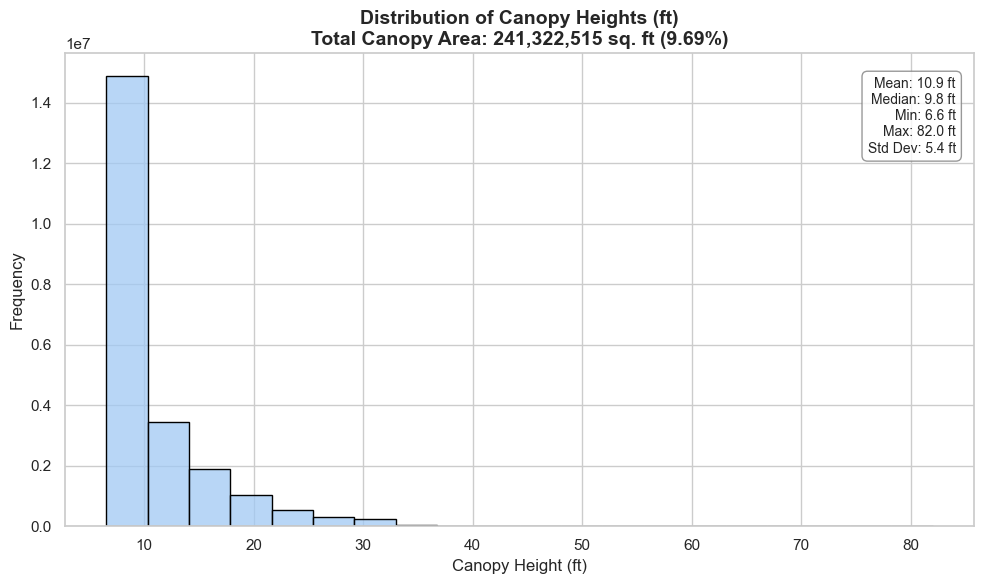

In [68]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(canopy_heights_ft, bins=20, kde=False,  edgecolor="black", ax=ax)

# Axis labels and title
ax.set_title(
    f"Distribution of Canopy Heights (ft)\n"
    f"Total Canopy Area: {total_canopy_area:,.0f} sq. ft "
    f"({total_canopy_cover_percent:.2f}%)",
    fontsize=14,
    weight='bold'
)
plt.xlabel('Canopy Height (ft)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Summary statistics text box
stats_text = (
    f"Mean: {mean_height_ft:.1f} ft\n"
    f"Median: {median_height_ft:.1f} ft\n"
    f"Min: {min_height_ft:.1f} ft\n"
    f"Max: {max_height_ft:.1f} ft\n"
    f"Std Dev: {std_dev_height_ft:.1f} ft"
)

# Position text box in top right corner
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10, ha='right', va='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)



plt.tight_layout()
plt.show()

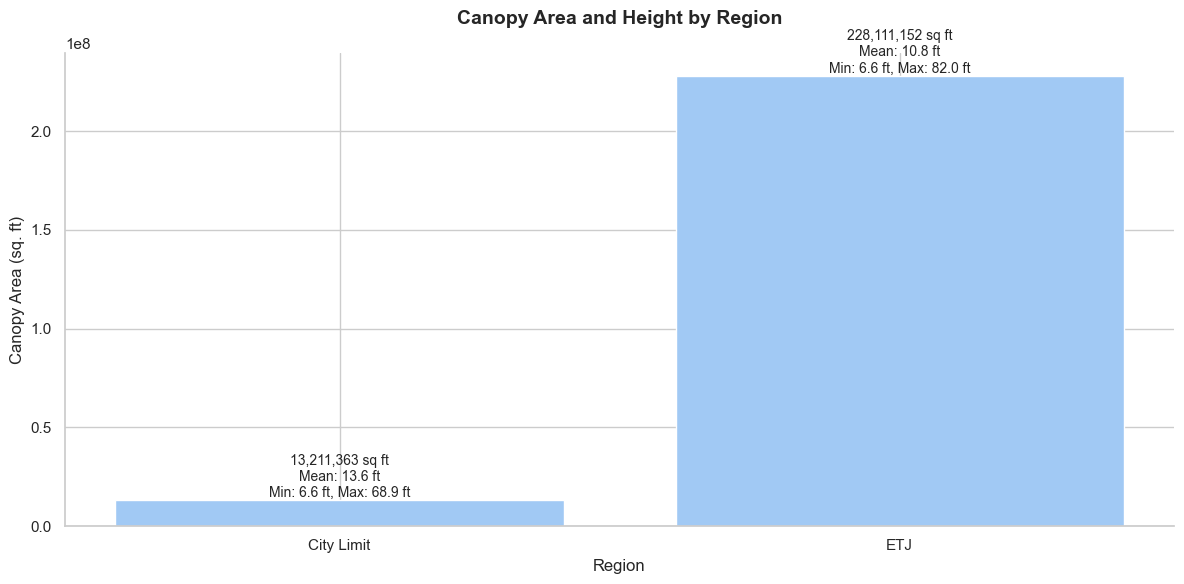

In [69]:



# Setup figure
fig, ax = plt.subplots(figsize=(12, 6))

# Draw bar chart
bars = ax.bar(
    grouped_stats["place"],
    grouped_stats["canopy_area"]
)

# Add area + height annotations to each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    region = grouped_stats.iloc[i]

    mean_ht = region["canopy_mean"]
    min_ht = region["canopy_min"]
    max_ht = region["canopy_max"]

    label = (
        f"{height:,.0f} sq ft\n"
        f"Mean: {mean_ht:.1f} ft\n"
        f"Min: {min_ht:.1f} ft, Max: {max_ht:.1f} ft"
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 20000,
        label,
        ha='center',
        va='bottom',
        fontsize=10
    )

# Titles and styling
ax.set_title(
    f"Canopy Area and Height by Region\n",
    fontsize=14,
    weight='bold'
)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Canopy Area (sq. ft)", fontsize=12)
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# Percentages

In [70]:
def calculate_region_understory_overstory_stats(geometry, canopy_raster, transform):
    """Calculate understory and overstory stats for a specific polygon region."""
    region_mask = rasterio.features.geometry_mask(
        [geometry], transform=transform, invert=True, out_shape=canopy_raster.shape
    )

    understory_mask = (canopy_raster >= 2) & (canopy_raster < 3) & region_mask
    overstory_mask = (canopy_raster >= 3) & region_mask

    understory_area = np.sum(understory_mask) * pixel_area
    overstory_area = np.sum(overstory_mask) * pixel_area
    region_area = np.sum(region_mask) * pixel_area

    understory_percent = (understory_area / region_area) * 100 if region_area > 0 else 0
    overstory_percent = (overstory_area / region_area) * 100 if region_area > 0 else 0

    return {
        'understory_area': understory_area,
        'understory_percent': understory_percent,
        'overstory_area': overstory_area,
        'overstory_percent': overstory_percent
    }

In [71]:
# %% Apply Stats Calculation to Each Region in the GeoDataFrame
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)
    transform = src.transform

    stats = []
    for _, row in gdf.iterrows():
        stats.append(calculate_region_understory_overstory_stats(row.geometry, canopy_data, transform))

In [72]:

# Convert stats to a DataFrame and merge with GeoDataFrame
stats_df = pd.DataFrame(stats)


In [73]:
print(stats_df)

   understory_area  understory_percent  overstory_area  overstory_percent
0        8445526.0            4.118993      12746714.0           6.216739
1         338852.0            1.279229        888525.0           3.354345


In [74]:
gdf = pd.concat([gdf, stats_df], axis=1)
gdf

,place,area,geometry,min,max,mean,count,canopy_area,canopy_mean,canopy_median,canopy_min,canopy_max,canopy_std,understory_area,understory_percent,overstory_area,overstory_percent
0,ETJ,2.205216e+09,"MULTIPOLYGON (((758461.056 3637905.555, 758653...",1.0,25.0,2.503875,32258464,2.281112e+08,10.791250,9.84252,6.56168,82.02100,5.229162,8445526.0,4.118993,12746714.0,6.216739
1,City Limit,2.848915e+08,"MULTIPOLYGON (((757421.329 3630536.373, 757419...",1.0,21.0,3.140618,1801480,1.321136e+07,13.588872,13.12336,6.56168,68.89764,7.065915,338852.0,1.279229,888525.0,3.354345


In [75]:
gdf['total_tree_cover_percent'] = (gdf['canopy_area'] / gdf['area']) * 100


# %% Group by Region and Summarize
summary_stats = gdf.groupby('place').agg({
    'total_tree_cover_percent': 'mean',
    'understory_area': 'sum',
    'overstory_area': 'sum',
    'understory_percent': 'mean',
    'overstory_percent': 'mean'
}).reset_index()


# %% Display Results
print(summary_stats)


        place  total_tree_cover_percent  understory_area  overstory_area  \
0  City Limit                  4.637331         338852.0        888525.0   
1         ETJ                 10.344164        8445526.0      12746714.0   

   understory_percent  overstory_percent  
0            1.279229           3.354345  
1            4.118993           6.216739  


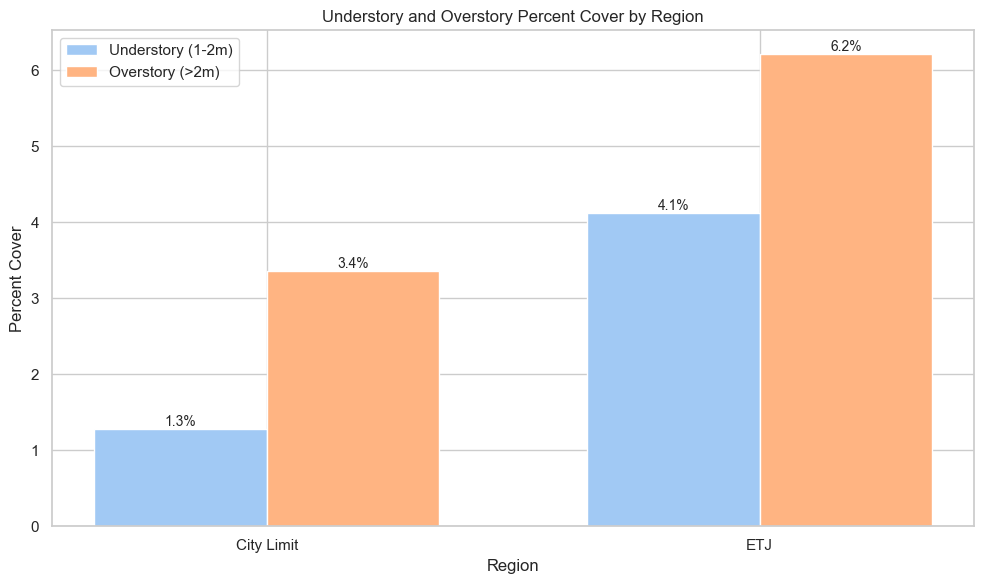

In [76]:

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(summary_stats))

# Create the bars
understory_bars = ax.bar(index, summary_stats['understory_percent'], bar_width, label='Understory (1-2m)')
overstory_bars = ax.bar(index + bar_width, summary_stats['overstory_percent'], bar_width, label='Overstory (>2m)')

# Add annotations
for bar in understory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,  # Position text at center of the bar
        f"{height:.1f}%",  # Format the text
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

for bar in overstory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

# Set plot labels and title
ax.set_title('Understory and Overstory Percent Cover by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Percent Cover')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary_stats['place'])
ax.legend()

plt.tight_layout()
plt.show()


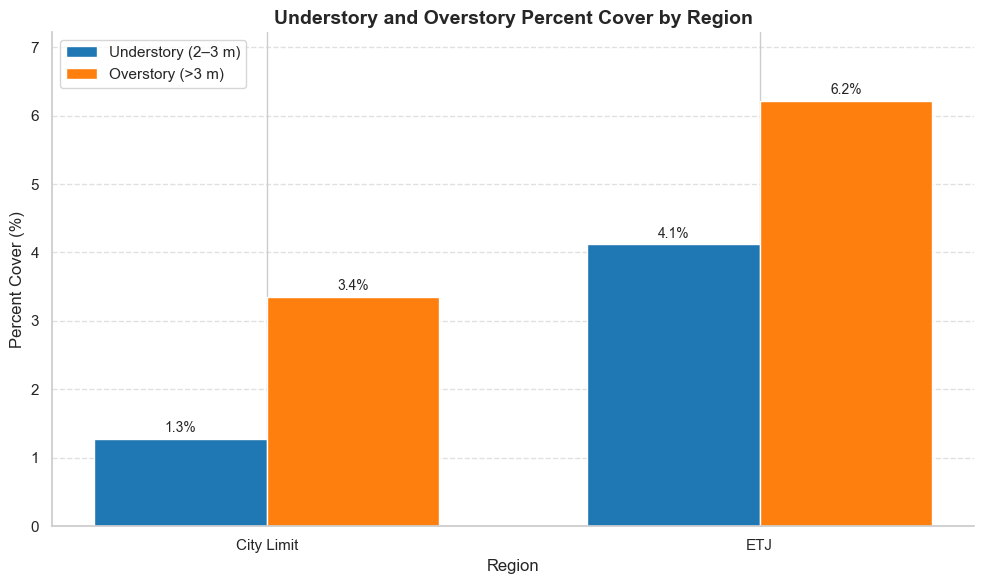

In [77]:


fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(summary_stats))

# Custom color palette
under_color = "#1f77b4"   # soft blue
over_color = "#ff7f0e"    # soft orange

# Create the bars
understory_bars = ax.bar(index, summary_stats['understory_percent'], bar_width, label='Understory (2–3 m)', color=under_color)
overstory_bars = ax.bar(index + bar_width, summary_stats['overstory_percent'], bar_width, label='Overstory (>3 m)', color=over_color)

# Add annotations to bars
for bar in understory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.05,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

for bar in overstory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height + 0.05,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

# Set labels and style
ax.set_title('Understory and Overstory Percent Cover by Region', fontsize=14, weight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Percent Cover (%)', fontsize=12)
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary_stats['place'], fontsize=11)
ax.set_ylim(0, max(summary_stats['overstory_percent'].max(), summary_stats['understory_percent'].max()) + 1)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


# Combined Canopy Statistics Markdown 

In [78]:


combined_canopy_markdown = f"""
# Canopy Structure Summary for Study Area

This summary includes three levels of analysis:
1. General canopy statistics across the full study area
2. Height-based statistics for all canopy (height > 2 meters)
3. A tiered breakdown of understory (2–3 m) and overstory (>3 m) vegetation by region

---

## 1. Study Area Canopy Statistics

**Total Tree Canopy Cover across Study Area:** {total_canopy_cover_percent:.2f}%  

The table below summarizes total land area, canopy extent, and height distribution across **all pixels with vegetation ≥ 2 meters** in the study area. These statistics reflect a direct pixel-based analysis.

| Total Area (ft²) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Median Height (ft) | Std Dev Height (ft) | Total Canopy Area (ft²) |
|------------------|------------------------|------------------------|------------------|----------------------|---------------------------|---------------------------|
| {gdf['area'].sum():,.0f} | {min_height_ft:.2f} | {max_height_ft:.2f} | {mean_height_ft:.2f} | {median_height_ft:.2f} | {std_dev_height_ft:.2f} | {total_canopy_area:,.0f} |

---


---

## 2. Regional Tree Cover Overview

This section summarizes how much of each region is covered by trees taller than 2 meters, along with average canopy height statistics.

Unlike the pixel-based statistics in Section 1, the height values below are **region-level summaries** derived from zonal statistics — meaning each region contributes **equally**, regardless of how much canopy it contains. This helps highlight variation between communities.


| Region | Canopy Area (sq ft) | Region Area (sq ft) | Tree Cover (%) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) |
|--------|----------------------|----------------------|----------------|------------------|---------------------|------------------|------------------|
"""

for _, row in gdf.iterrows():
    combined_canopy_markdown += (
        f"| {row['place']} | "
        f"{row['canopy_area']:,.0f} | "
        f"{row['area']:,.0f} | "
        f"{row['total_tree_cover_percent']:.2f} | "
        f"{row['canopy_mean']:.2f} | "
        f"{row['canopy_median']:.2f} | "
        f"{row['canopy_min']:.2f} | "
        f"{row['canopy_max']:.2f} |\n"
    )


combined_canopy_markdown += f"""

> **Note:**  
> The "Total Tree Canopy Cover" is calculated by dividing the combined canopy area by the total area across all regions.  
> The individual region percentages show the proportion of each region’s area that is covered by trees.  
> These values may not appear to add up because each percentage is based on different denominators (each region's own size).  

---

## 3. Tiered Canopy Structure by Region

This section provides a breakdown of canopy height into two distinct tiers:
- **Understory (2–3 meters)**
- **Overstory (>3 meters)**

The percentages show how much of each region is covered by trees in each tier.

| Region | Understory Area (ft²) | Overstory Area (ft²) | Understory (%) | Overstory (%) |
|--------|------------------------|------------------------|----------------|----------------|
"""

for _, row in gdf.iterrows():
    combined_canopy_markdown += (
        f"| {row['place']} | {row['understory_area']:.2f} | {row['overstory_area']:.2f} | "
        f"{row['understory_percent']:.2f} | {row['overstory_percent']:.2f} |\n"
    )

combined_canopy_markdown += """
- **Understory and Overstory Percent**: These values represent the share of canopy that is composed of understory (2–3 m) or overstory (>3 m) vegetation **within each region**.
- These percentages are calculated using **total canopy area in the region as the denominator**, not the total land area. This allows us to understand the relative vertical structure of the canopy where it exists.
- For example, if a region has 10,000 sq ft of canopy, and 3,000 sq ft of that is trees between 2–3 meters tall, the understory percent will be 30%.

> **Reminder:** Section 2.1 gives the percent of the region’s total area that is covered by trees. Section 3 gives the percent of canopy area that falls into each height tier.
"""

print(combined_canopy_markdown)



# Canopy Structure Summary for Study Area

This summary includes three levels of analysis:
1. General canopy statistics across the full study area
2. Height-based statistics for all canopy (height > 2 meters)
3. A tiered breakdown of understory (2–3 m) and overstory (>3 m) vegetation by region

---

## 1. Study Area Canopy Statistics

**Total Tree Canopy Cover across Study Area:** 9.69%  

The table below summarizes total land area, canopy extent, and height distribution across **all pixels with vegetation ≥ 2 meters** in the study area. These statistics reflect a direct pixel-based analysis.

| Total Area (ft²) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Median Height (ft) | Std Dev Height (ft) | Total Canopy Area (ft²) |
|------------------|------------------------|------------------------|------------------|----------------------|---------------------------|---------------------------|
| 2,490,107,413 | 6.56 | 82.02 | 10.94 | 9.84 | 5.38 | 241,322,515 |




# Canopy Structure Summary for Study Area

This summary includes three levels of analysis:
1. General canopy statistics across the full study area
2. Height-based statistics for all canopy (height > 2 meters)
3. A tiered breakdown of understory (2–3 m) and overstory (>3 m) vegetation by region

---

## 1. Study Area Canopy Statistics

**Total Tree Canopy Cover across Study Area:** 9.69%  

The table below summarizes total land area, canopy extent, and height distribution across **all pixels with vegetation ≥ 2 meters** in the study area. These statistics reflect a direct pixel-based analysis.

| Total Area (ft²) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Median Height (ft) | Std Dev Height (ft) | Total Canopy Area (ft²) |
|------------------|------------------------|------------------------|------------------|----------------------|---------------------------|---------------------------|
| 2,490,107,413 | 6.56 | 82.02 | 10.94 | 9.84 | 5.38 | 241,322,515 |

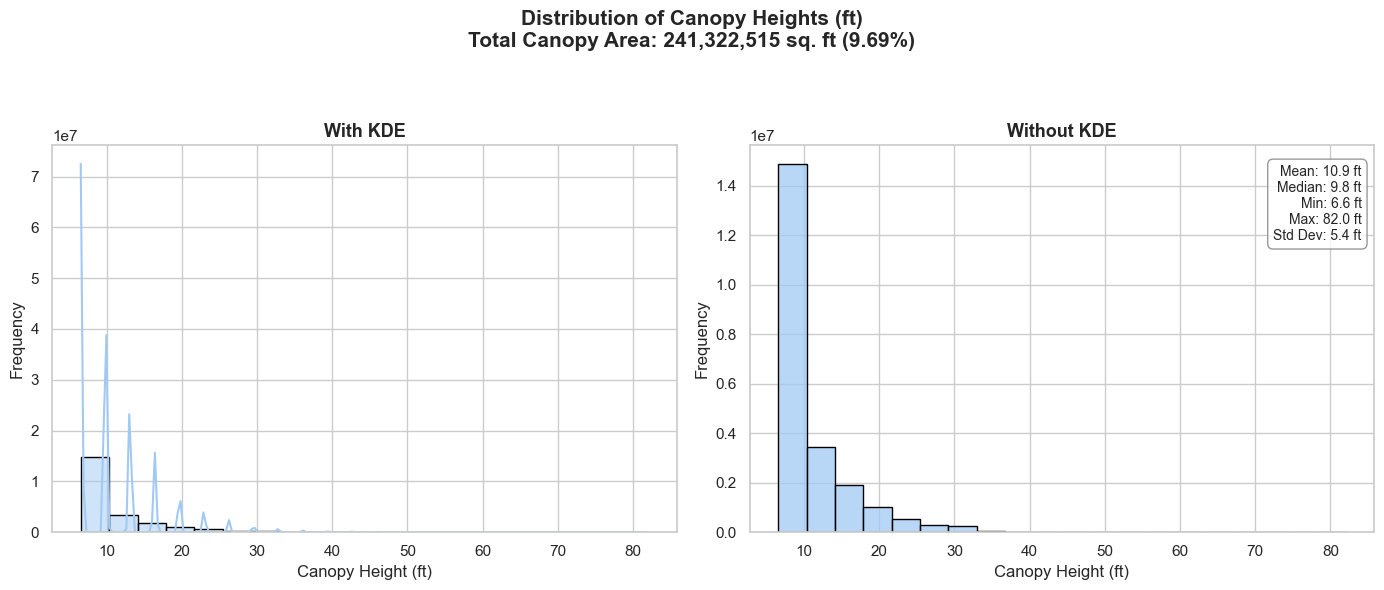


---


---

## 2. Regional Tree Cover Overview

This section summarizes how much of each region is covered by trees taller than 2 meters, along with average canopy height statistics.

Unlike the pixel-based statistics in Section 1, the height values below are **region-level summaries** derived from zonal statistics — meaning each region contributes **equally**, regardless of how much canopy it contains. This helps highlight variation between communities.


| Region | Canopy Area (sq ft) | Region Area (sq ft) | Tree Cover (%) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) |
|--------|----------------------|----------------------|----------------|------------------|---------------------|------------------|------------------|
| ETJ | 228,111,152 | 2,205,215,898 | 10.34 | 10.79 | 9.84 | 6.56 | 82.02 |
| City Limit | 13,211,363 | 284,891,515 | 4.64 | 13.59 | 13.12 | 6.56 | 68.90 |

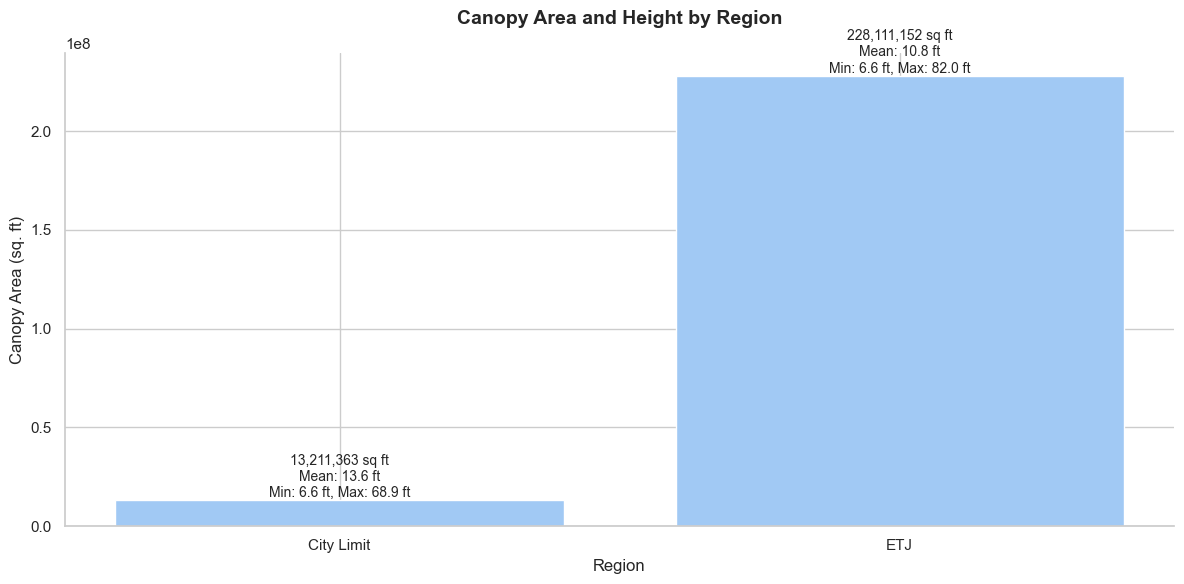

> **Note:**  
> The "Total Tree Canopy Cover" is calculated by dividing the combined canopy area by the total area across all regions.  
> The individual region percentages show the proportion of each region’s area that is covered by trees.  
> These values may not appear to add up because each percentage is based on different denominators (each region's own size).  

---

## 3. Tiered Canopy Structure by Region

This section provides a breakdown of canopy height into two distinct tiers:
- **Understory (2–3 meters)**
- **Overstory (>3 meters)**

The percentages show how much of each region is covered by trees in each tier.

| Region | Understory Area (ft²) | Overstory Area (ft²) | Understory (%) | Overstory (%) |
|--------|------------------------|------------------------|----------------|----------------|
| ETJ | 8445526.00 | 12746714.00 | 4.12 | 6.22 |
| City Limit | 338852.00 | 888525.00 | 1.28 | 3.35 |

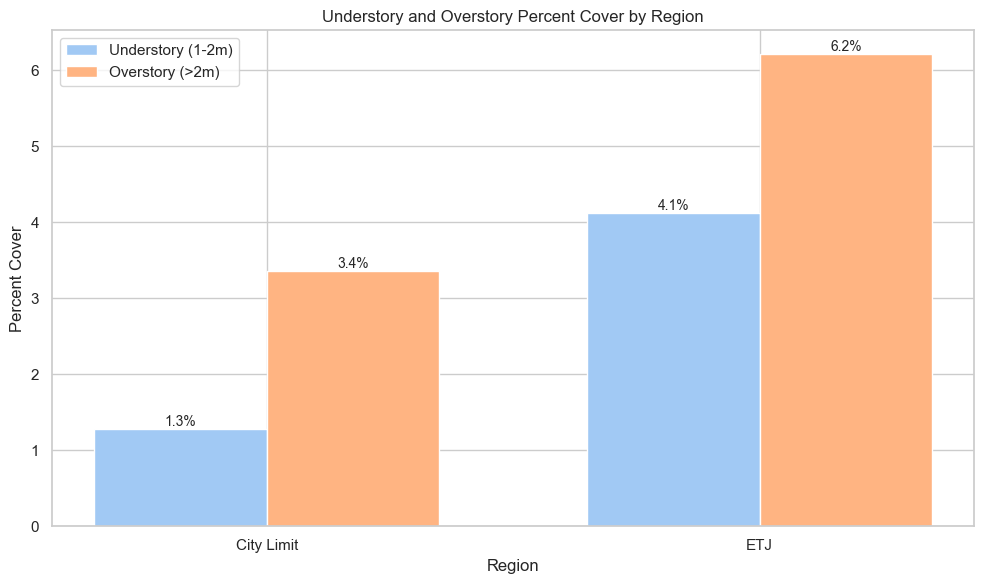

- **Understory and Overstory Percent**: These values represent the share of canopy that is composed of understory (2–3 m) or overstory (>3 m) vegetation **within each region**.
- These percentages are calculated using **total canopy area in the region as the denominator**, not the total land area. This allows us to understand the relative vertical structure of the canopy where it exists.
- For example, if a region has 10,000 sq ft of canopy, and 3,000 sq ft of that is trees between 2–3 meters tall, the understory percent will be 30%.

> **Reminder:** Section 2.1 gives the percent of the region’s total area that is covered by trees. Section 3 gives the percent of canopy area that falls into each height tier.


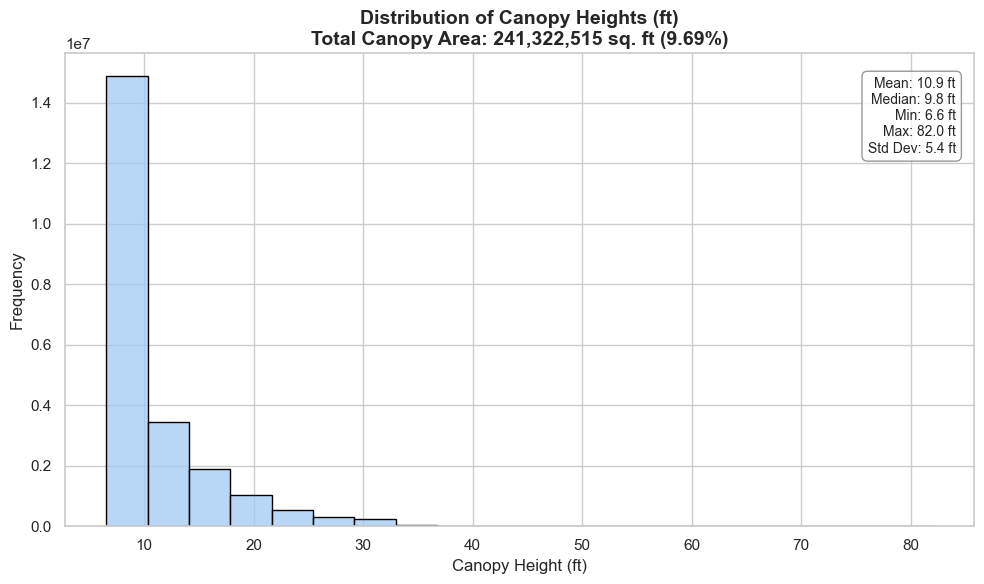
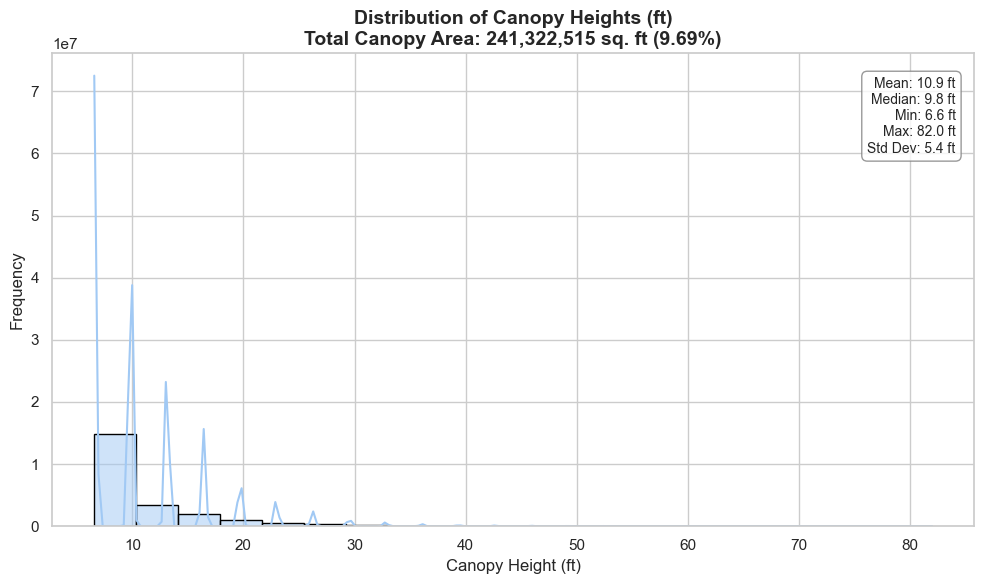

In [79]:
gdf

,place,area,geometry,min,max,mean,count,canopy_area,canopy_mean,canopy_median,canopy_min,canopy_max,canopy_std,understory_area,understory_percent,overstory_area,overstory_percent,total_tree_cover_percent
0,ETJ,2.205216e+09,"MULTIPOLYGON (((758461.056 3637905.555, 758653...",1.0,25.0,2.503875,32258464,2.281112e+08,10.791250,9.84252,6.56168,82.02100,5.229162,8445526.0,4.118993,12746714.0,6.216739,10.344164
1,City Limit,2.848915e+08,"MULTIPOLYGON (((757421.329 3630536.373, 757419...",1.0,21.0,3.140618,1801480,1.321136e+07,13.588872,13.12336,6.56168,68.89764,7.065915,338852.0,1.279229,888525.0,3.354345,4.637331


In [80]:
#gdf.to_file(nm_path, layer='hurley_tc_ft', driver='GPKG')